In [1]:
# 1-Core Data Processing and Visualization Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2-Scikit-learn Tools for Preprocessing and Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 3-Library for Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# 4-Machine Learning Models and Evaluation Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# 1 - EDA
--- Section 1: Exploratory Data Analysis (EDA) ---

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

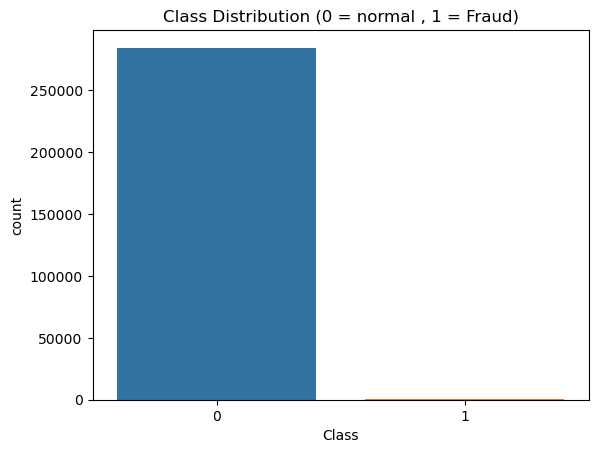

In [5]:
# Class distribution (imblanced Data)
sns.countplot(x = 'Class', data = df)
plt.title("Class Distribution (0 = normal , 1 = Fraud)")
plt.show()

In [6]:
# Percentage of fraud cases
fraud_percent = (df['Class'].value_counts()[1] / len(df) * 100)
print(f"Fraud cases: {fraud_percent}%")

Fraud cases: 0.1727485630620034%


D:\Programs\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Programs\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


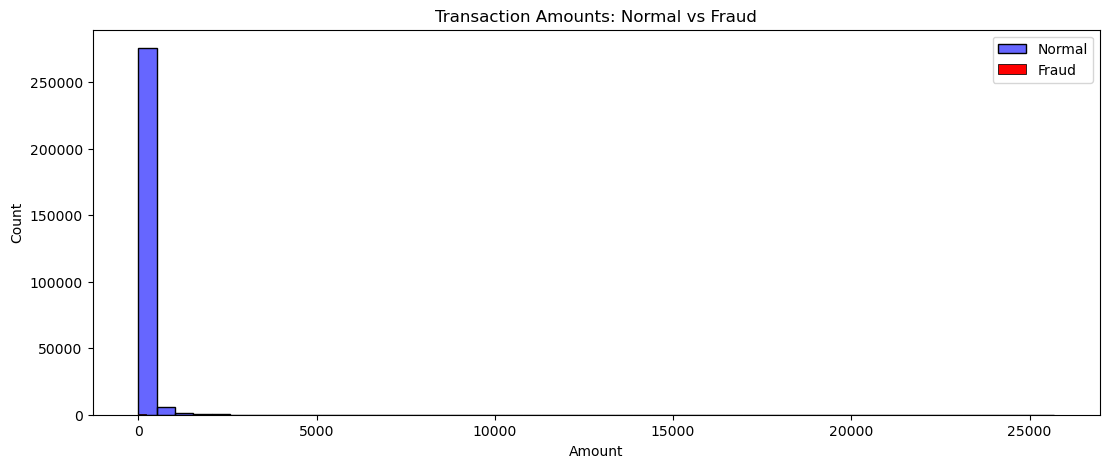

In [7]:
# Transaction amount by class
plt.figure(figsize=(13,5))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Normal', alpha=0.6)
sns.histplot(df[df['Class']==1]['Amount'], bins=10, color='red', label='Fraud', alpha=1)
plt.legend()
plt.title("Transaction Amounts: Normal vs Fraud")
plt.show()

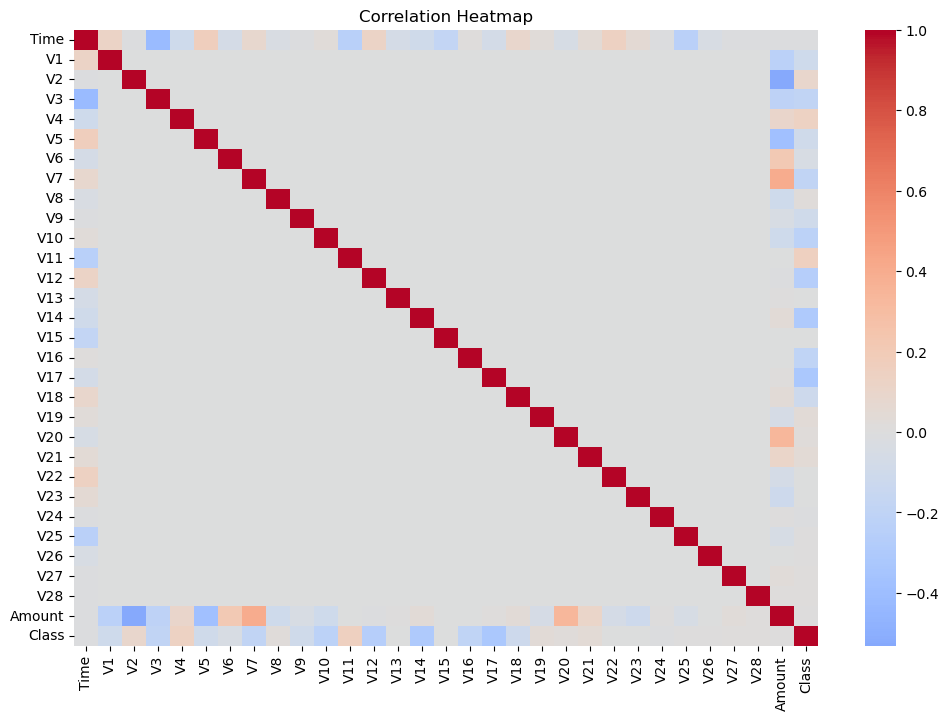

In [8]:
# Correlation heatmap (quick look at relationships)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# 2 - Scaling and splitting
--- Section 2: Data Preprocessing (Scaling and Splitting) ---

In [9]:
# Copy dataframe to avoid overwriting
data = df.copy()

# Scale some feature
scaler = StandardScaler()
data[['Time', 'Amount']] = scaler.fit_transform(data[['Time', 'Amount']])
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.641931,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350151,0
284803,1.641952,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254117,0
284804,1.641974,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.081839,0
284805,1.641974,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313249,0


In [10]:
# features X and Y
X = data.drop('Class', axis = 1)
y = data['Class']

# Split features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# Ensuring the class distribution is maintained in both train and test sets (crucial for imbalanced data).

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud cases in train:", y_train.sum())
print("Fraud cases in test:", y_test.sum())

Train size: (227845, 30)
Test size: (56962, 30)
Fraud cases in train: 394
Fraud cases in test: 98


# 3 - Handling Imbalance with SMOTE
--- Section 3: Oversampling the Training Data using SMOTE ---

# Baseline Model (Without SMOTE)
In this step, we will train a **Logistic Regression model** on the original imbalanced dataset, without applying any resampling technique.  
This baseline will help us observe how class imbalance affects model performance.  
Later, we will compare these results with a Logistic Regression model trained after applying **SMOTE** to see the improvement.

In [11]:
lr = LogisticRegression(max_iter = 1000, random_state = 42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [12]:
# Predictions
y_pred = lr.predict(X_test)
y_pred_prob = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Logistic Regression Report:

              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

ROC-AUC Score: 0.9572835078037969


# Handle Imbalance data with SMOTE

In [13]:
smot = SMOTE(random_state = 42)
X_train_resample, y_train_resample = smot.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts(), "\n")
print("After SMOTE:", y_train_resample.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64 

After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


# 4 - Modeling and Evaluation
--- Section 4: Training Models and Evaluating Performance ---

In [14]:
# LogisticRegression
lr = LogisticRegression(max_iter = 1000, random_state = 42)
lr.fit(X_train_resample, y_train_resample)

LogisticRegression(max_iter=1000, random_state=42)

In [15]:
# Predictions
y_pred = lr.predict(X_test)
y_pred_prob = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Logistic Regression Report:

              precision    recall  f1-score   support

           0     0.9999    0.9744    0.9869     56864
           1     0.0581    0.9184    0.1094        98

    accuracy                         0.9743     56962
   macro avg     0.5290    0.9464    0.5481     56962
weighted avg     0.9982    0.9743    0.9854     56962

ROC-AUC Score: 0.9698482164390798


In [16]:
# RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resample, y_train_resample)

RandomForestClassifier(random_state=42)

In [17]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob_rf))

Random Forest Report:

              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8454    0.8367    0.8410        98

    accuracy                         0.9995     56962
   macro avg     0.9225    0.9182    0.9204     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC Score: 0.973103297664029
